# Early Detection of Depression Using Reddit Text (Text Classification)

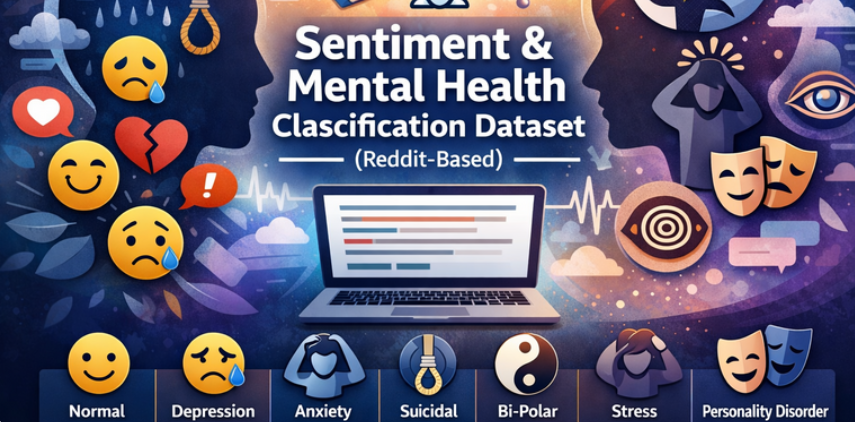

## Content

This dataset contains Reddit posts labeled into multiple mental health categories such as Depression, Anxiety, Bipolar, and Suicidal. The objective of this project is to build a machine learning model that can automatically detect whether a given post reflects depression based on its textual content.

Since the dataset is text-based, it cannot be directly used by machine learning algorithms. Therefore, it requires preprocessing and transformation into numerical form using techniques such as TF-IDF vectorization.

The original dataset is a multi-class classification problem. However, for simplicity and practical relevance, it is transformed into a binary classification task:

**1 → Depression**

**0 → Other mental health categories**

This transformation allows us to apply supervised learning algorithms such as Logistic Regression, Support Vector Machines (SVM), Naive Bayes, and Random Forest for classification.

Additionally, the dataset exhibits class imbalance, which plays an important role in evaluating model performance and requires careful consideration of evaluation metrics such as recall and F1-score.


## 1. Importing Libraries

In [20]:
# !pip install pandas numpy scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss
)

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-pastel')
pd.set_option('display.max_columns', 500)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Import Data

In [21]:
# Load dataset
reddit_df = pd.read_csv('Sentiment_Mental_health_dataset.csv')

# Preview
reddit_df.head()
print("Dataset shape:", reddit_df.shape)

Dataset shape: (26350, 2)


## 3. Preliminary Data Analysis

In [22]:
reddit_df.info()
reddit_df.describe(include='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26350 entries, 0 to 26349
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  26350 non-null  object
 1   status     26350 non-null  object
dtypes: object(2)
memory usage: 411.8+ KB


,statement,status
count,26350,26350
unique,26329,7
top,.,Suicidal
freq,4,5600


**First Conclusions:**

-> Dataset contains text + categorical labels

-> No major structural issues

-> Requires text preprocessing + feature extraction

-> Multi-class problem → converted into binary classification

## 4. Exploratory Data Analysis (EDA)

### Class Distribution

To begin, let's examine the dataset by viewing its first few rows, shape, and basic information. This helps us understand the structure of the data before applying any preprocessing or modeling techniques

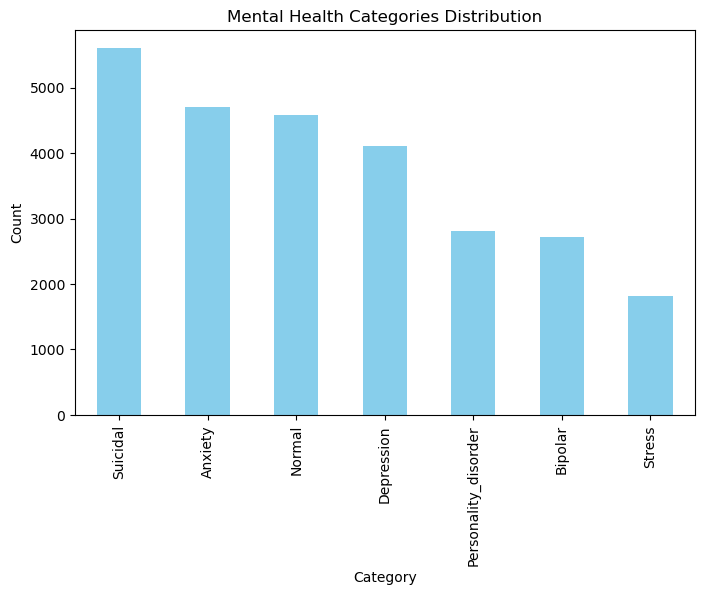

In [23]:
reddit_df['status'].value_counts().plot(
    kind='bar', figsize=(8,5), color='skyblue'
)
plt.title("Mental Health Categories Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

## Binary Label Creation

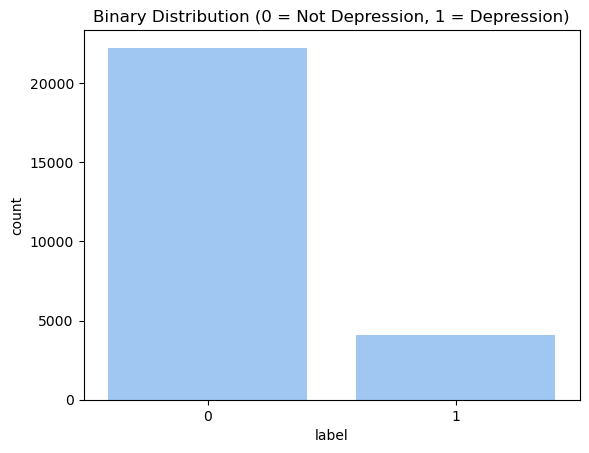

In [24]:
reddit_df['label'] = reddit_df['status'].apply(
    lambda x: 1 if x.lower() == 'depression' else 0
)

sns.countplot(x='label', data=reddit_df)
plt.title("Binary Distribution (0 = Not Depression, 1 = Depression)")
plt.show()

**Observations:**

Dataset is **imbalanced**

Depression class is smaller than non-depression

Important for model evaluation (recall matters)

## 5. Feature Engineering

### Text Preprocessing

In [25]:
# Lowercase conversion
reddit_df['text'] = reddit_df['statement'].str.lower()

X_text = reddit_df['text']
y = reddit_df['label']

### TF-IDF Encoding

In [26]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=8000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(X_text)

print("TF-IDF shape:", X.shape)

TF-IDF shape: (26350, 8000)


### Train-Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 6. Model Development

### Initialize Models


In [28]:
lr = LogisticRegression(max_iter=1000)
svm = LinearSVC()
nb = MultinomialNB()
rf = RandomForestClassifier(n_estimators=150, random_state=42)

### Train Models

In [29]:
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
nb.fit(X_train, y_train)
rf.fit(X_train, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 7. Model Evaluation

### 🔹Logistic Regression

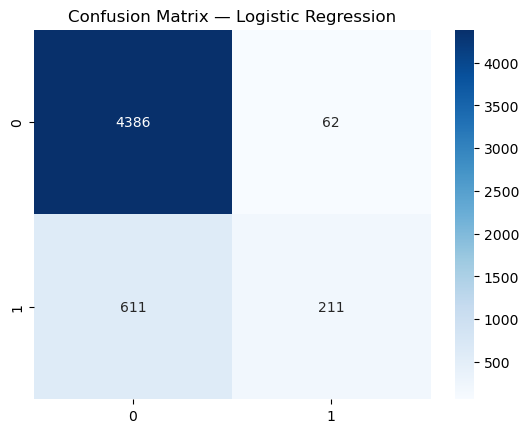

Accuracy  --> 0.8722960151802657
Precision --> 0.7728937728937729
Recall    --> 0.25669099756691
F1 Score  --> 0.38538812785388127
Log Loss  --> 0.3016457316446853


In [30]:
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:,1]

cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

print("Accuracy  -->", accuracy_score(y_test, y_pred_lr))
print("Precision -->", precision_score(y_test, y_pred_lr))
print("Recall    -->", recall_score(y_test, y_pred_lr))
print("F1 Score  -->", f1_score(y_test, y_pred_lr))
print("Log Loss  -->", log_loss(y_test, y_proba_lr))

### 🔹SVM Classifier

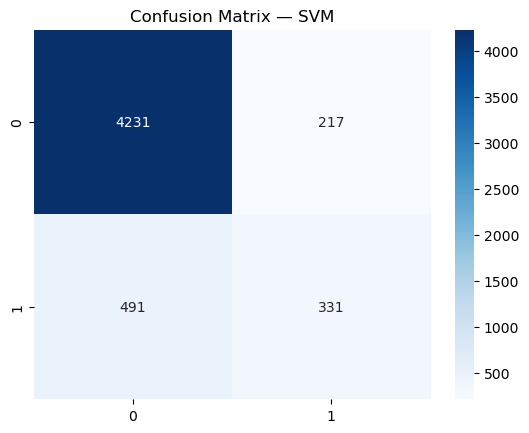

Accuracy  --> 0.8656546489563567
Precision --> 0.6040145985401459
Recall    --> 0.402676399026764
F1 Score  --> 0.4832116788321168


In [31]:
y_pred_svm = svm.predict(X_test)

cm_svm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — SVM")
plt.show()

print("Accuracy  -->", accuracy_score(y_test, y_pred_svm))
print("Precision -->", precision_score(y_test, y_pred_svm))
print("Recall    -->", recall_score(y_test, y_pred_svm))
print("F1 Score  -->", f1_score(y_test, y_pred_svm))

### 🔹Naive Bayes

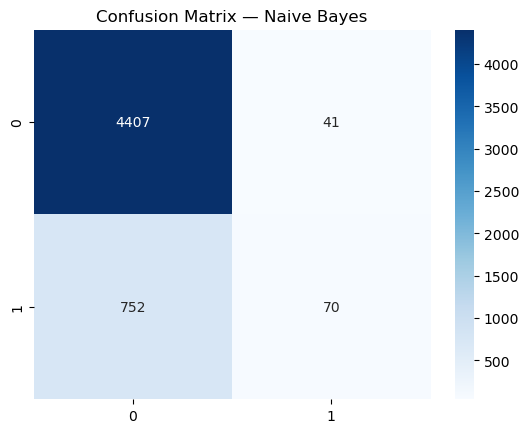

Accuracy  --> 0.8495256166982922
Precision --> 0.6306306306306306
Recall    --> 0.0851581508515815
F1 Score  --> 0.15005359056806003
Log Loss  --> 0.3381016465072167


In [32]:
y_pred_nb = nb.predict(X_test)
y_proba_nb = nb.predict_proba(X_test)[:,1]

cm_nb = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — Naive Bayes")
plt.show()

print("Accuracy  -->", accuracy_score(y_test, y_pred_nb))
print("Precision -->", precision_score(y_test, y_pred_nb))
print("Recall    -->", recall_score(y_test, y_pred_nb))
print("F1 Score  -->", f1_score(y_test, y_pred_nb))
print("Log Loss  -->", log_loss(y_test, y_proba_nb))

### 🔹 Random Forest

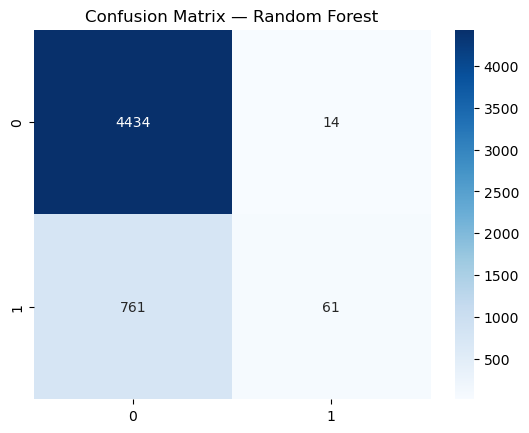

Accuracy  --> 0.8529411764705882
Precision --> 0.8133333333333334
Recall    --> 0.07420924574209246
F1 Score  --> 0.13600891861761427
Log Loss  --> 0.3492056865645455


In [33]:
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — Random Forest")
plt.show()

print("Accuracy  -->", accuracy_score(y_test, y_pred_rf))
print("Precision -->", precision_score(y_test, y_pred_rf))
print("Recall    -->", recall_score(y_test, y_pred_rf))
print("F1 Score  -->", f1_score(y_test, y_pred_rf))
print("Log Loss  -->", log_loss(y_test, y_proba_rf))

## Model Performance Analysis

The results show that although the model achieves high accuracy, this is misleading due to class imbalance in the dataset. The majority of samples belong to the non-depression class, causing the model to bias its predictions toward that class.

In the case of Random Forest, the model achieves high precision, which indicates that when it predicts a post as depressive, it is usually correct. However, the recall is extremely low, meaning the model fails to identify most of the actual depression cases.

This highlights a key issue in imbalanced classification problems: accuracy alone is not sufficient. Metrics such as recall and F1-score provide a better understanding of model performance, especially when detecting minority classes like depression is the main objective.

# 8. Conclusion

Being a text-based classification problem, this project demonstrates how Natural Language Processing (NLP) techniques can be effectively combined with machine learning models to detect depression from social media data.

After preprocessing the text and converting it into numerical features using TF-IDF, multiple models were trained and evaluated. Among them, Logistic Regression and SVM showed relatively better performance in balancing precision and recall.

However, due to class imbalance in the dataset, most models struggled with low recall, meaning many depression cases were not correctly identified. This highlights an important limitation and suggests that future improvements should focus on handling imbalance using techniques such as resampling (SMOTE) or advanced models like deep learning.

Overall, this project shows that machine learning has strong potential for early depression detection, but careful handling of data imbalance and evaluation metrics is crucial for building reliable systems.